# 07 — Cross-Subreddit Comparison: r/GradAdmissions vs r/MSCS

Loads pre-computed pipeline outputs from both subreddits and produces a side-by-side
comparison of:
- Anchor post volume and distress characteristics
- Panel coverage and exposure rates
- PSM-matched DiD ATT estimates (primary analysis)
- Pre/post mh_score distributions
- Statistical test for difference between subreddit ATT estimates

**Prerequisites:** Run NB01–NB06 for both `SUBREDDIT='gradadmissions'` and `SUBREDDIT='mscs'`
before running this notebook.

**Inputs:**
- `data/processed_v2/gradadmissions/*.parquet`
- `data/processed_v2/mscs/*.parquet`

**Outputs:**
- `figures/fig_att_comparison.png` — forest plot: ATT coefficients for both subreddits
- `figures/fig_mhscore_distributions.png` — boxplot: pre/post mh_score by subreddit
- `figures/fig_anchor_comparison.png` — anchor post characteristics side by side
- `data/processed_v2/comparison_summary.parquet` — all key metrics in one table

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pathlib import Path
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

ROOT    = Path('..').resolve()
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

SUBREDDITS = {
    'gradadmissions': ROOT / 'data' / 'processed_v2' / 'gradadmissions',
    'mscs':           ROOT / 'data' / 'processed_v2' / 'mscs',
}

REQUIRED = [
    'panel_scores_v2.parquet',
    'anchor_posts_v2.parquet',
    'exposure_labels_v2.parquet',
    'user_community_breadth_v2.parquet',
]

print('Checking required files...')
all_ok = True
for sr, ddir in SUBREDDITS.items():
    for fname in REQUIRED:
        exists = (ddir / fname).exists()
        status = 'OK' if exists else 'MISSING'
        if not exists:
            all_ok = False
        print(f'  r/{sr}/{fname}: {status}')

if not all_ok:
    print('\n⚠ Some files are missing — run NB01–NB06 for both subreddits first.')
else:
    print('\nAll files present.')

Checking required files...
  r/gradadmissions/panel_scores_v2.parquet: OK
  r/gradadmissions/anchor_posts_v2.parquet: OK
  r/gradadmissions/exposure_labels_v2.parquet: OK
  r/gradadmissions/user_community_breadth_v2.parquet: OK
  r/mscs/panel_scores_v2.parquet: OK
  r/mscs/anchor_posts_v2.parquet: OK
  r/mscs/exposure_labels_v2.parquet: OK
  r/mscs/user_community_breadth_v2.parquet: OK

All files present.


## 1) Panel and anchor post summary

In [13]:
summary_rows = []

for sr, ddir in SUBREDDITS.items():
    panel    = pd.read_parquet(ddir / 'panel_scores_v2.parquet')
    anchors  = pd.read_parquet(ddir / 'anchor_posts_v2.parquet')
    exposure = pd.read_parquet(ddir / 'exposure_labels_v2.parquet')

    for cycle in [1, 2]:
        pc = panel[panel['cycle'] == cycle]
        ec = exposure[exposure['cycle'] == cycle]
        ac = anchors[anchors['cycle'].isin([cycle, float(cycle)])]
        summary_rows.append({
            'subreddit':              f'r/{sr}',
            'cycle':                  cycle,
            'total_panel_users':      len(ec),
            'n_exposed':              int(ec['exposed'].sum()),
            'n_unexposed':            int((~ec['exposed']).sum()),
            'exposure_rate_pct':      round(100 * ec['exposed'].mean(), 2),
            'n_users_w_pre_post':     len(pc),
            'n_anchor_posts':         len(ac),
            'mean_anchor_mh_score':   round(ac['mean_mh_score'].mean(), 4) if len(ac) else np.nan,
            'mean_anchor_score':      round(ac['score'].mean(), 1) if len(ac) else np.nan,
            'mean_anchor_n_comments': round(ac['num_comments'].mean(), 1) if len(ac) else np.nan,
        })

summary_df = pd.DataFrame(summary_rows)
print('=== Panel & Anchor Post Summary ===')
print(summary_df.to_string(index=False))

=== Panel & Anchor Post Summary ===
       subreddit  cycle  total_panel_users  n_exposed  n_unexposed  exposure_rate_pct  n_users_w_pre_post  n_anchor_posts  mean_anchor_mh_score  mean_anchor_score  mean_anchor_n_comments
r/gradadmissions      1               9953       1185         8768              11.91                3701             449                0.4909               10.2                     6.0
r/gradadmissions      2              12316       1599        10717              12.98                4069             548                0.4836               15.6                     6.7
          r/mscs      1               1440        131         1309               9.10                 772              36                0.4190                3.4                     7.6
          r/mscs      2               2859        243         2616               8.50                1179              64                0.4127                8.3                     8.5


## 2) Anchor post characteristics comparison

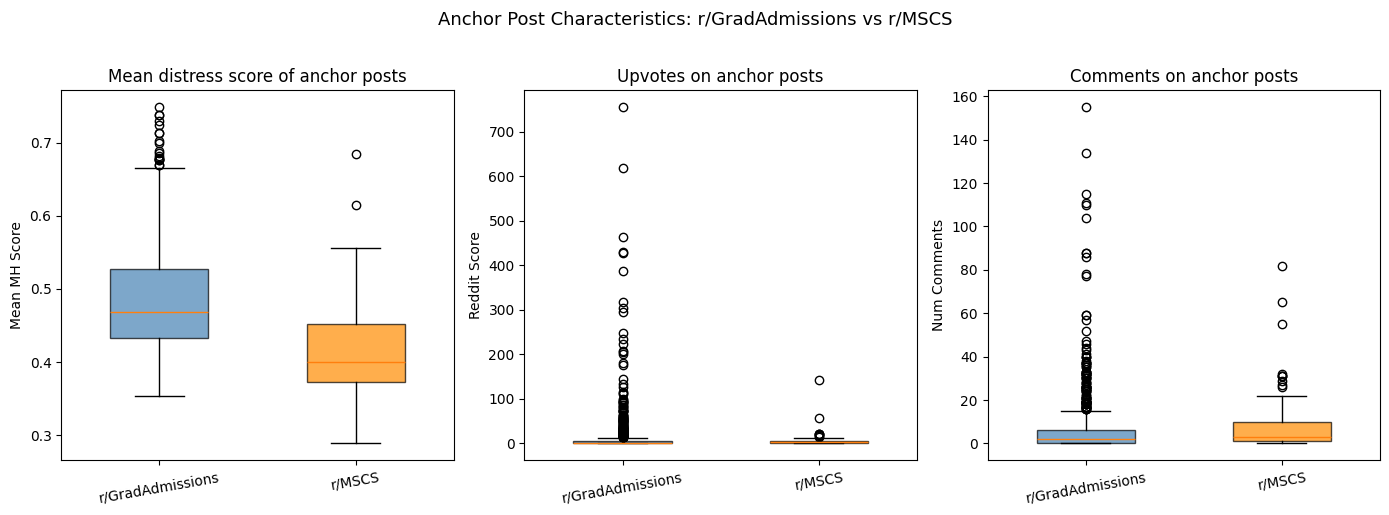

r/gradadmissions: 997 anchor posts | mean_mh=0.4869 | score=13.2 | comments=6.4
r/mscs: 100 anchor posts | mean_mh=0.4150 | score=6.5 | comments=8.2


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

anchor_data = {}
for sr, ddir in SUBREDDITS.items():
    anchor_data[sr] = pd.read_parquet(ddir / 'anchor_posts_v2.parquet')

metrics = [
    ('mean_mh_score', 'Mean MH Score', 'Mean distress score of anchor posts'),
    ('score',         'Reddit Score',  'Upvotes on anchor posts'),
    ('num_comments',  'Num Comments',  'Comments on anchor posts'),
]

colors = {'gradadmissions': 'steelblue', 'mscs': 'darkorange'}
labels = {'gradadmissions': 'r/GradAdmissions', 'mscs': 'r/MSCS'}

for ax, (col, ylabel, title) in zip(axes, metrics):
    data_to_plot = [anchor_data[sr][col].dropna().values for sr in ['gradadmissions', 'mscs']]
    bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.5)
    for patch, sr in zip(bp['boxes'], ['gradadmissions', 'mscs']):
        patch.set_facecolor(colors[sr])
        patch.set_alpha(0.7)
    ax.set_xticklabels([labels[sr] for sr in ['gradadmissions', 'mscs']], rotation=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plt.suptitle('Anchor Post Characteristics: r/GradAdmissions vs r/MSCS', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_anchor_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

for sr in ['gradadmissions', 'mscs']:
    a = anchor_data[sr]
    print(f'r/{sr}: {len(a):,} anchor posts | mean_mh={a["mean_mh_score"].mean():.4f} | '
          f'score={a["score"].mean():.1f} | comments={a["num_comments"].mean():.1f}')

## 3) PSM + DiD helper functions (reused from NB06)

In [15]:
CALIPER       = 0.05
MATCH_FEATURES = ['pre_mh_score', 'log1p_n_posts_pre']


def psm_match(df, features, caliper):
    """1:1 nearest-neighbor PSM; returns (matched_author_set, n_pairs, clean_df)."""
    clean = df.dropna(subset=features).copy()
    X = StandardScaler().fit_transform(clean[features])
    y = clean['exposed'].astype(int).values
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X, y)
    clean['pscore'] = lr.predict_proba(X)[:, 1]
    exp_df   = clean[clean['exposed']].reset_index(drop=True)
    unexp_df = clean[~clean['exposed']].reset_index(drop=True)
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(unexp_df[['pscore']])
    dists, idxs = nn.kneighbors(exp_df[['pscore']])
    matched_authors = set()
    for i, (dist, idx) in enumerate(zip(dists.flatten(), idxs.flatten())):
        if dist <= caliper:
            matched_authors.add(exp_df.loc[i, 'author'])
            matched_authors.add(unexp_df.loc[idx, 'author'])
    n_pairs = sum(1 for d in dists.flatten() if d <= caliper)
    return matched_authors, n_pairs, clean


def build_long_df(panel_sub, matched_authors, cycle):
    """Reshape matched panel rows to long format (period 0/1)."""
    rows = []
    for _, row in panel_sub[panel_sub['author'].isin(matched_authors)].iterrows():
        base = {'author': row['author'], 'cycle': cycle, 'exposed': int(row['exposed'])}
        rows.append({**base, 'period': 0, 'mh_score': row['pre_mh_score'],  'n_posts': row['pre_n_posts']})
        rows.append({**base, 'period': 1, 'mh_score': row['post_mh_score'], 'n_posts': row['post_n_posts']})
    df = pd.DataFrame(rows)
    df['period_x_exposed'] = df['period'] * df['exposed']
    df['log1p_n_posts']    = np.log1p(df['n_posts'])
    return df


def run_did(df, label=''):
    """Run DiD regression; return fitted model."""
    m = smf.ols(
        'mh_score ~ period + exposed + period_x_exposed + log1p_n_posts',
        data=df.dropna(subset=['mh_score'])
    ).fit(cov_type='HC3')
    coef = m.params['period_x_exposed']
    pval = m.pvalues['period_x_exposed']
    ci   = m.conf_int().loc['period_x_exposed']
    sig  = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'n.s.'))
    if label:
        print(f'  {label:<25}  DiD={coef:+.4f} [{ci[0]:+.4f}, {ci[1]:+.4f}]  p={pval:.4f} {sig}  n={int(m.nobs):,}')
    return m


print('Helper functions defined.')

Helper functions defined.


## 4) Run PSM + DiD for both subreddits

In [16]:
all_results  = {}   # sr -> {models, long_df, n_pairs_by_cycle}
all_long_dfs = {}   # sr -> combined long_df (both cycles)

for sr, ddir in SUBREDDITS.items():
    print(f'\n=== r/{sr} ===')
    panel   = pd.read_parquet(ddir / 'panel_scores_v2.parquet')
    breadth_path = ddir / 'user_community_breadth_v2.parquet'
    if breadth_path.exists():
        breadth = pd.read_parquet(breadth_path)
        panel = panel.merge(breadth[['author', 'community_breadth', 'community_breadth_log']],
                            on='author', how='left')
    panel['log1p_n_posts_pre'] = np.log1p(panel['pre_n_posts'])

    matched_by_cycle = {}
    n_pairs_by_cycle = {}
    long_rows_all    = []

    for cycle in [1, 2]:
        sub = panel[panel['cycle'] == cycle].copy()
        authors, n_pairs, _ = psm_match(sub, MATCH_FEATURES, CALIPER)
        matched_by_cycle[cycle] = authors
        n_pairs_by_cycle[cycle] = n_pairs
        print(f'  Cycle {cycle}: {n_pairs:,} matched pairs')
        long_rows_all.append(build_long_df(sub, authors, cycle))

    long_df = pd.concat(long_rows_all, ignore_index=True)
    all_long_dfs[sr] = long_df

    print(f'  DiD results (HC3 SEs):')
    models = {}
    for cycle in [1, 2]:
        models[cycle] = run_did(long_df[long_df['cycle'] == cycle], f'Cycle {cycle}')

    pool = long_df.copy()
    pool['cycle_fe'] = pool['cycle'].astype(str)
    m_pool = smf.ols(
        'mh_score ~ period + exposed + period_x_exposed + log1p_n_posts + C(cycle_fe)',
        data=pool.dropna(subset=['mh_score'])
    ).fit(cov_type='HC3')
    models['pooled'] = m_pool

    coef_p = m_pool.params['period_x_exposed']
    pval_p = m_pool.pvalues['period_x_exposed']
    ci_p   = m_pool.conf_int().loc['period_x_exposed']
    sig_p  = '***' if pval_p < 0.001 else ('**' if pval_p < 0.01 else ('*' if pval_p < 0.05 else 'n.s.'))
    print(f'  {"Pooled (+cycle FE)":<25}  DiD={coef_p:+.4f} [{ci_p[0]:+.4f}, {ci_p[1]:+.4f}]  p={pval_p:.4f} {sig_p}  n={int(m_pool.nobs):,}')

    all_results[sr] = {'models': models, 'long_df': long_df, 'n_pairs': n_pairs_by_cycle}


=== r/gradadmissions ===
  Cycle 1: 438 matched pairs
  Cycle 2: 490 matched pairs
  DiD results (HC3 SEs):
  Cycle 1                    DiD=+0.0059 [-0.0046, +0.0165]  p=0.2713 n.s.  n=1,664
  Cycle 2                    DiD=+0.0027 [-0.0073, +0.0127]  p=0.5971 n.s.  n=1,844
  Pooled (+cycle FE)         DiD=+0.0043 [-0.0029, +0.0116]  p=0.2446 n.s.  n=3,508

=== r/mscs ===
  Cycle 1: 78 matched pairs
  Cycle 2: 113 matched pairs
  DiD results (HC3 SEs):
  Cycle 1                    DiD=-0.0044 [-0.0254, +0.0167]  p=0.6849 n.s.  n=298
  Cycle 2                    DiD=+0.0133 [-0.0023, +0.0289]  p=0.0955 n.s.  n=428
  Pooled (+cycle FE)         DiD=+0.0062 [-0.0063, +0.0188]  p=0.3316 n.s.  n=726


## 5) ATT coefficient comparison plot (forest plot)

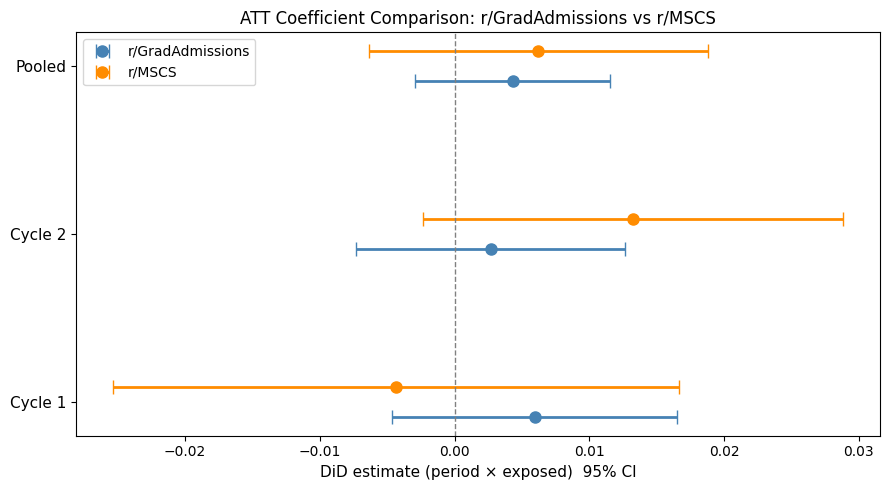

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

sr_colors  = {'gradadmissions': 'steelblue',  'mscs': 'darkorange'}
sr_labels  = {'gradadmissions': 'r/GradAdmissions', 'mscs': 'r/MSCS'}
spec_keys  = [1, 2, 'pooled']
spec_names = ['Cycle 1', 'Cycle 2', 'Pooled']
n_specs    = len(spec_keys)
offset     = 0.18   # vertical offset between subreddits at same spec

for si, sr in enumerate(['gradadmissions', 'mscs']):
    models = all_results[sr]['models']
    y_positions = [i + (si - 0.5) * offset for i in range(n_specs)]
    coefs, lo, hi = [], [], []
    for key in spec_keys:
        m  = models[key]
        c  = m.params['period_x_exposed']
        ci = m.conf_int().loc['period_x_exposed']
        coefs.append(c)
        lo.append(ci[0])
        hi.append(ci[1])
    ax.errorbar(
        coefs, y_positions,
        xerr=[np.array(coefs) - np.array(lo), np.array(hi) - np.array(coefs)],
        fmt='o', color=sr_colors[sr], label=sr_labels[sr],
        capsize=5, linewidth=2, markersize=8,
    )

ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(range(n_specs))
ax.set_yticklabels(spec_names, fontsize=11)
ax.set_xlabel('DiD estimate (period × exposed)  95% CI', fontsize=11)
ax.set_title('ATT Coefficient Comparison: r/GradAdmissions vs r/MSCS', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_att_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6) Pre/post mh_score distributions

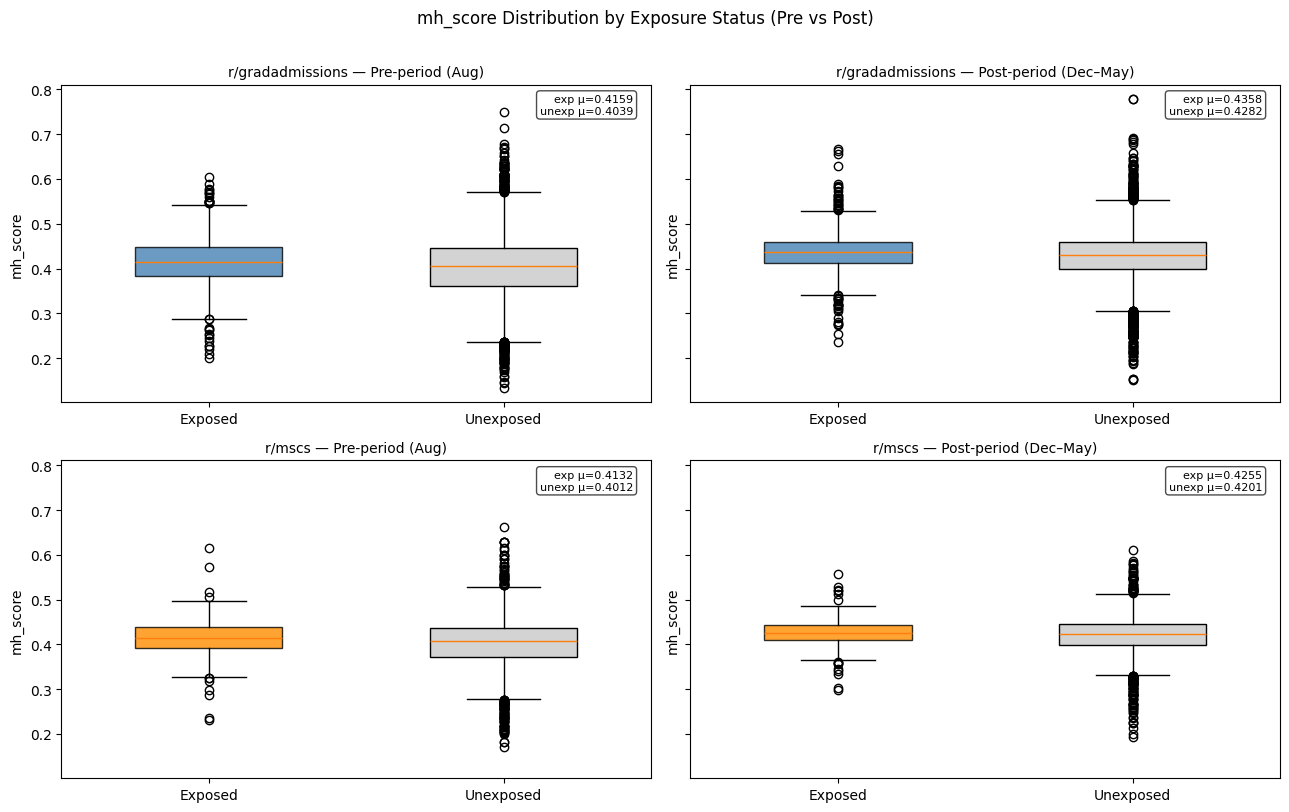

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)

for row_idx, sr in enumerate(['gradadmissions', 'mscs']):
    ddir  = SUBREDDITS[sr]
    panel = pd.read_parquet(ddir / 'panel_scores_v2.parquet')
    color = sr_colors[sr]

    for col_idx, (period_col, period_label) in enumerate(
        [('pre_mh_score', 'Pre-period (Aug)'), ('post_mh_score', 'Post-period (Dec–May)')]
    ):
        ax = axes[row_idx][col_idx]
        exp_vals   = panel[panel['exposed']  ][period_col].dropna()
        unexp_vals = panel[~panel['exposed'] ][period_col].dropna()
        bp = ax.boxplot([exp_vals, unexp_vals], patch_artist=True,
                        labels=['Exposed', 'Unexposed'], widths=0.5)
        bp['boxes'][0].set_facecolor(color)
        bp['boxes'][0].set_alpha(0.8)
        bp['boxes'][1].set_facecolor('lightgray')
        ax.set_title(f'r/{sr} — {period_label}', fontsize=10)
        ax.set_ylabel('mh_score')
        ax.text(0.97, 0.97,
                f'exp μ={exp_vals.mean():.4f}\nunexp μ={unexp_vals.mean():.4f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('mh_score Distribution by Exposure Status (Pre vs Post)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_mhscore_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7) Statistical test: are the ATT estimates significantly different between subreddits?

Uses a Z-test on the pooled ATT coefficients: `Z = (coef_GA - coef_MSCS) / sqrt(se_GA^2 + se_MSCS^2)`

In [19]:
print('=== Z-test: Difference in Pooled ATT between subreddits ===')
print()

rows_ztest = []
for spec_key, spec_name in zip(spec_keys, spec_names):
    m_ga   = all_results['gradadmissions']['models'][spec_key]
    m_mscs = all_results['mscs']['models'][spec_key]

    coef_ga   = m_ga.params['period_x_exposed']
    coef_mscs = m_mscs.params['period_x_exposed']

    # HC3 standard errors
    se_ga   = m_ga.bse['period_x_exposed']
    se_mscs = m_mscs.bse['period_x_exposed']

    diff = coef_ga - coef_mscs
    se_diff = np.sqrt(se_ga**2 + se_mscs**2)
    z_stat  = diff / se_diff
    p_val   = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'n.s.'))

    print(f'{spec_name}:')
    print(f'  r/GradAdmissions ATT = {coef_ga:+.4f} (SE={se_ga:.4f})')
    print(f'  r/MSCS           ATT = {coef_mscs:+.4f} (SE={se_mscs:.4f})')
    print(f'  Difference           = {diff:+.4f}  Z={z_stat:.3f}  p={p_val:.4f} {sig}')
    print()

    rows_ztest.append({
        'spec':           spec_name,
        'att_gradadmissions': round(coef_ga,   4),
        'se_gradadmissions':  round(se_ga,     4),
        'att_mscs':           round(coef_mscs, 4),
        'se_mscs':            round(se_mscs,   4),
        'diff_GA_minus_MSCS': round(diff,      4),
        'z_stat':             round(z_stat,    3),
        'p_val':              round(p_val,     4),
        'sig':                sig,
    })

ztest_df = pd.DataFrame(rows_ztest)
print(ztest_df.to_string(index=False))

=== Z-test: Difference in Pooled ATT between subreddits ===

Cycle 1:
  r/GradAdmissions ATT = +0.0059 (SE=0.0054)
  r/MSCS           ATT = -0.0044 (SE=0.0107)
  Difference           = +0.0103  Z=0.857  p=0.3914 n.s.

Cycle 2:
  r/GradAdmissions ATT = +0.0027 (SE=0.0051)
  r/MSCS           ATT = +0.0133 (SE=0.0080)
  Difference           = -0.0106  Z=-1.120  p=0.2627 n.s.

Pooled:
  r/GradAdmissions ATT = +0.0043 (SE=0.0037)
  r/MSCS           ATT = +0.0062 (SE=0.0064)
  Difference           = -0.0019  Z=-0.260  p=0.7952 n.s.

   spec  att_gradadmissions  se_gradadmissions  att_mscs  se_mscs  diff_GA_minus_MSCS  z_stat  p_val  sig
Cycle 1              0.0059             0.0054   -0.0044   0.0107              0.0103   0.857 0.3914 n.s.
Cycle 2              0.0027             0.0051    0.0133   0.0080             -0.0106  -1.120 0.2627 n.s.
 Pooled              0.0043             0.0037    0.0062   0.0064             -0.0019  -0.260 0.7952 n.s.


## 8) Comprehensive summary table

In [20]:
comparison_rows = []

for sr, ddir in SUBREDDITS.items():
    panel    = pd.read_parquet(ddir / 'panel_scores_v2.parquet')
    anchors  = pd.read_parquet(ddir / 'anchor_posts_v2.parquet')
    exposure = pd.read_parquet(ddir / 'exposure_labels_v2.parquet')
    models   = all_results[sr]['models']
    n_pairs  = all_results[sr]['n_pairs']

    for cycle in [1, 2]:
        m   = models[cycle]
        ec  = exposure[exposure['cycle'] == cycle]
        ac  = anchors[anchors['cycle'].isin([cycle, float(cycle)])]
        coef = m.params['period_x_exposed']
        pval = m.pvalues['period_x_exposed']
        ci   = m.conf_int().loc['period_x_exposed']
        comparison_rows.append({
            'subreddit':         f'r/{sr}',
            'cycle':              cycle,
            'n_panel_users':      len(ec),
            'n_exposed':          int(ec['exposed'].sum()),
            'n_matched_pairs':    n_pairs[cycle],
            'n_anchor_posts':     len(ac),
            'mean_anchor_mh':     round(ac['mean_mh_score'].mean(), 4) if len(ac) else np.nan,
            'att_coef':           round(coef, 4),
            'att_ci_lo':          round(ci[0], 4),
            'att_ci_hi':          round(ci[1], 4),
            'att_pval':           round(pval, 4),
        })

    # Pooled row
    m_pool = models['pooled']
    coef_p = m_pool.params['period_x_exposed']
    pval_p = m_pool.pvalues['period_x_exposed']
    ci_p   = m_pool.conf_int().loc['period_x_exposed']
    comparison_rows.append({
        'subreddit':         f'r/{sr}',
        'cycle':              'pooled',
        'n_panel_users':      len(exposure),
        'n_exposed':          int(exposure['exposed'].sum()),
        'n_matched_pairs':    sum(n_pairs.values()),
        'n_anchor_posts':     len(anchors),
        'mean_anchor_mh':     round(anchors['mean_mh_score'].mean(), 4),
        'att_coef':           round(coef_p, 4),
        'att_ci_lo':          round(ci_p[0], 4),
        'att_ci_hi':          round(ci_p[1], 4),
        'att_pval':           round(pval_p, 4),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df['cycle'] = comparison_df['cycle'].astype(str)

print('=== Full Comparison Summary ===')
print(comparison_df.to_string(index=False))

# Save
OUT_PATH = ROOT / 'data' / 'processed_v2' / 'comparison_summary.parquet'
comparison_df.to_parquet(OUT_PATH, index=False)
print(f'\nSaved comparison_summary.parquet → {OUT_PATH}')

=== Full Comparison Summary ===
       subreddit  cycle  n_panel_users  n_exposed  n_matched_pairs  n_anchor_posts  mean_anchor_mh  att_coef  att_ci_lo  att_ci_hi  att_pval
r/gradadmissions      1           9953       1185              438             449          0.4909    0.0059    -0.0046     0.0165    0.2713
r/gradadmissions      2          12316       1599              490             548          0.4836    0.0027    -0.0073     0.0127    0.5971
r/gradadmissions pooled          22269       2784              928             997          0.4869    0.0043    -0.0029     0.0116    0.2446
          r/mscs      1           1440        131               78              36          0.4190   -0.0044    -0.0254     0.0167    0.6849
          r/mscs      2           2859        243              113              64          0.4127    0.0133    -0.0023     0.0289    0.0955
          r/mscs pooled           4299        374              191             100          0.4150    0.0062    -0.0063   